In [3]:
import pandas as pd
from cuml.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import cudf
import cuml
import os

In [2]:
# Load the dataset
data = pd.read_csv('../../../data/resample_minmax_all.csv')

# ✅ Extract the ID column (Never modified)
data_id = data["apogee_id"]

# ✅ Extract the Target columns (These are the prediction targets)
data_target = data[["TEFF", "J", "H", "K", "LOGG"]]

# ✅ Define the columns to drop (ID + categorical classifications + unnecessary features)
columns_to_drop = [
    "apogee_id", "TEFF", "J", "H", "K", "LOGG"
]

# Remove unwanted columns
data = data.drop(columns=columns_to_drop)

# ✅ Prepare final dataset for model training
data_scaled = data.copy()

# ✅ Convert to CUDF for GPU processing (if needed)
data_cudf = cudf.DataFrame(data_scaled)

# Display final dataset structure
print("✅ Data Loaded and Preprocessed Successfully!")
print(f"🆔 ID Columns: {data_id.shape}")
print(f"🎯 Target Columns: {data_target.shape}")
print(f"📊 Data for Model: {data_scaled.shape}")

✅ Data Loaded and Preprocessed Successfully!
🆔 ID Columns: (175770,)
🎯 Target Columns: (175770, 5)
📊 Data for Model: (175770, 17)


In [6]:
output_folder = "output_dataset"
os.makedirs(output_folder, exist_ok=True)

# List of desired dimensions
dimensions = [2, 3, 4]

for d in dimensions:
    # Initialize PCA for 'd' dimensions
    pca = cuml.decomposition.PCA(n_components=d)

    # Fit and transform the data with PCA
    data_projected = pca.fit_transform(data_cudf)

    # Convert the result to a pandas DataFrame
    data_projected_pd = data_projected.to_pandas()

    # Add the 'apogee_id' column to retain original identifiers
    data_projected_pd.insert(0, "apogee_id", data_id)

    # Define the output file name
    output_file = os.path.join(output_folder, f"PCA_latent_space_{d}D.csv")

    # Save the DataFrame as a CSV file
    data_projected_pd.to_csv(output_file, index=False)

    print(f"{d}D projection saved in {output_file}")


2D projection saved in output_dataset/PCA_latent_space_2D.csv
3D projection saved in output_dataset/PCA_latent_space_3D.csv
4D projection saved in output_dataset/PCA_latent_space_4D.csv


2D projection loaded successfully.


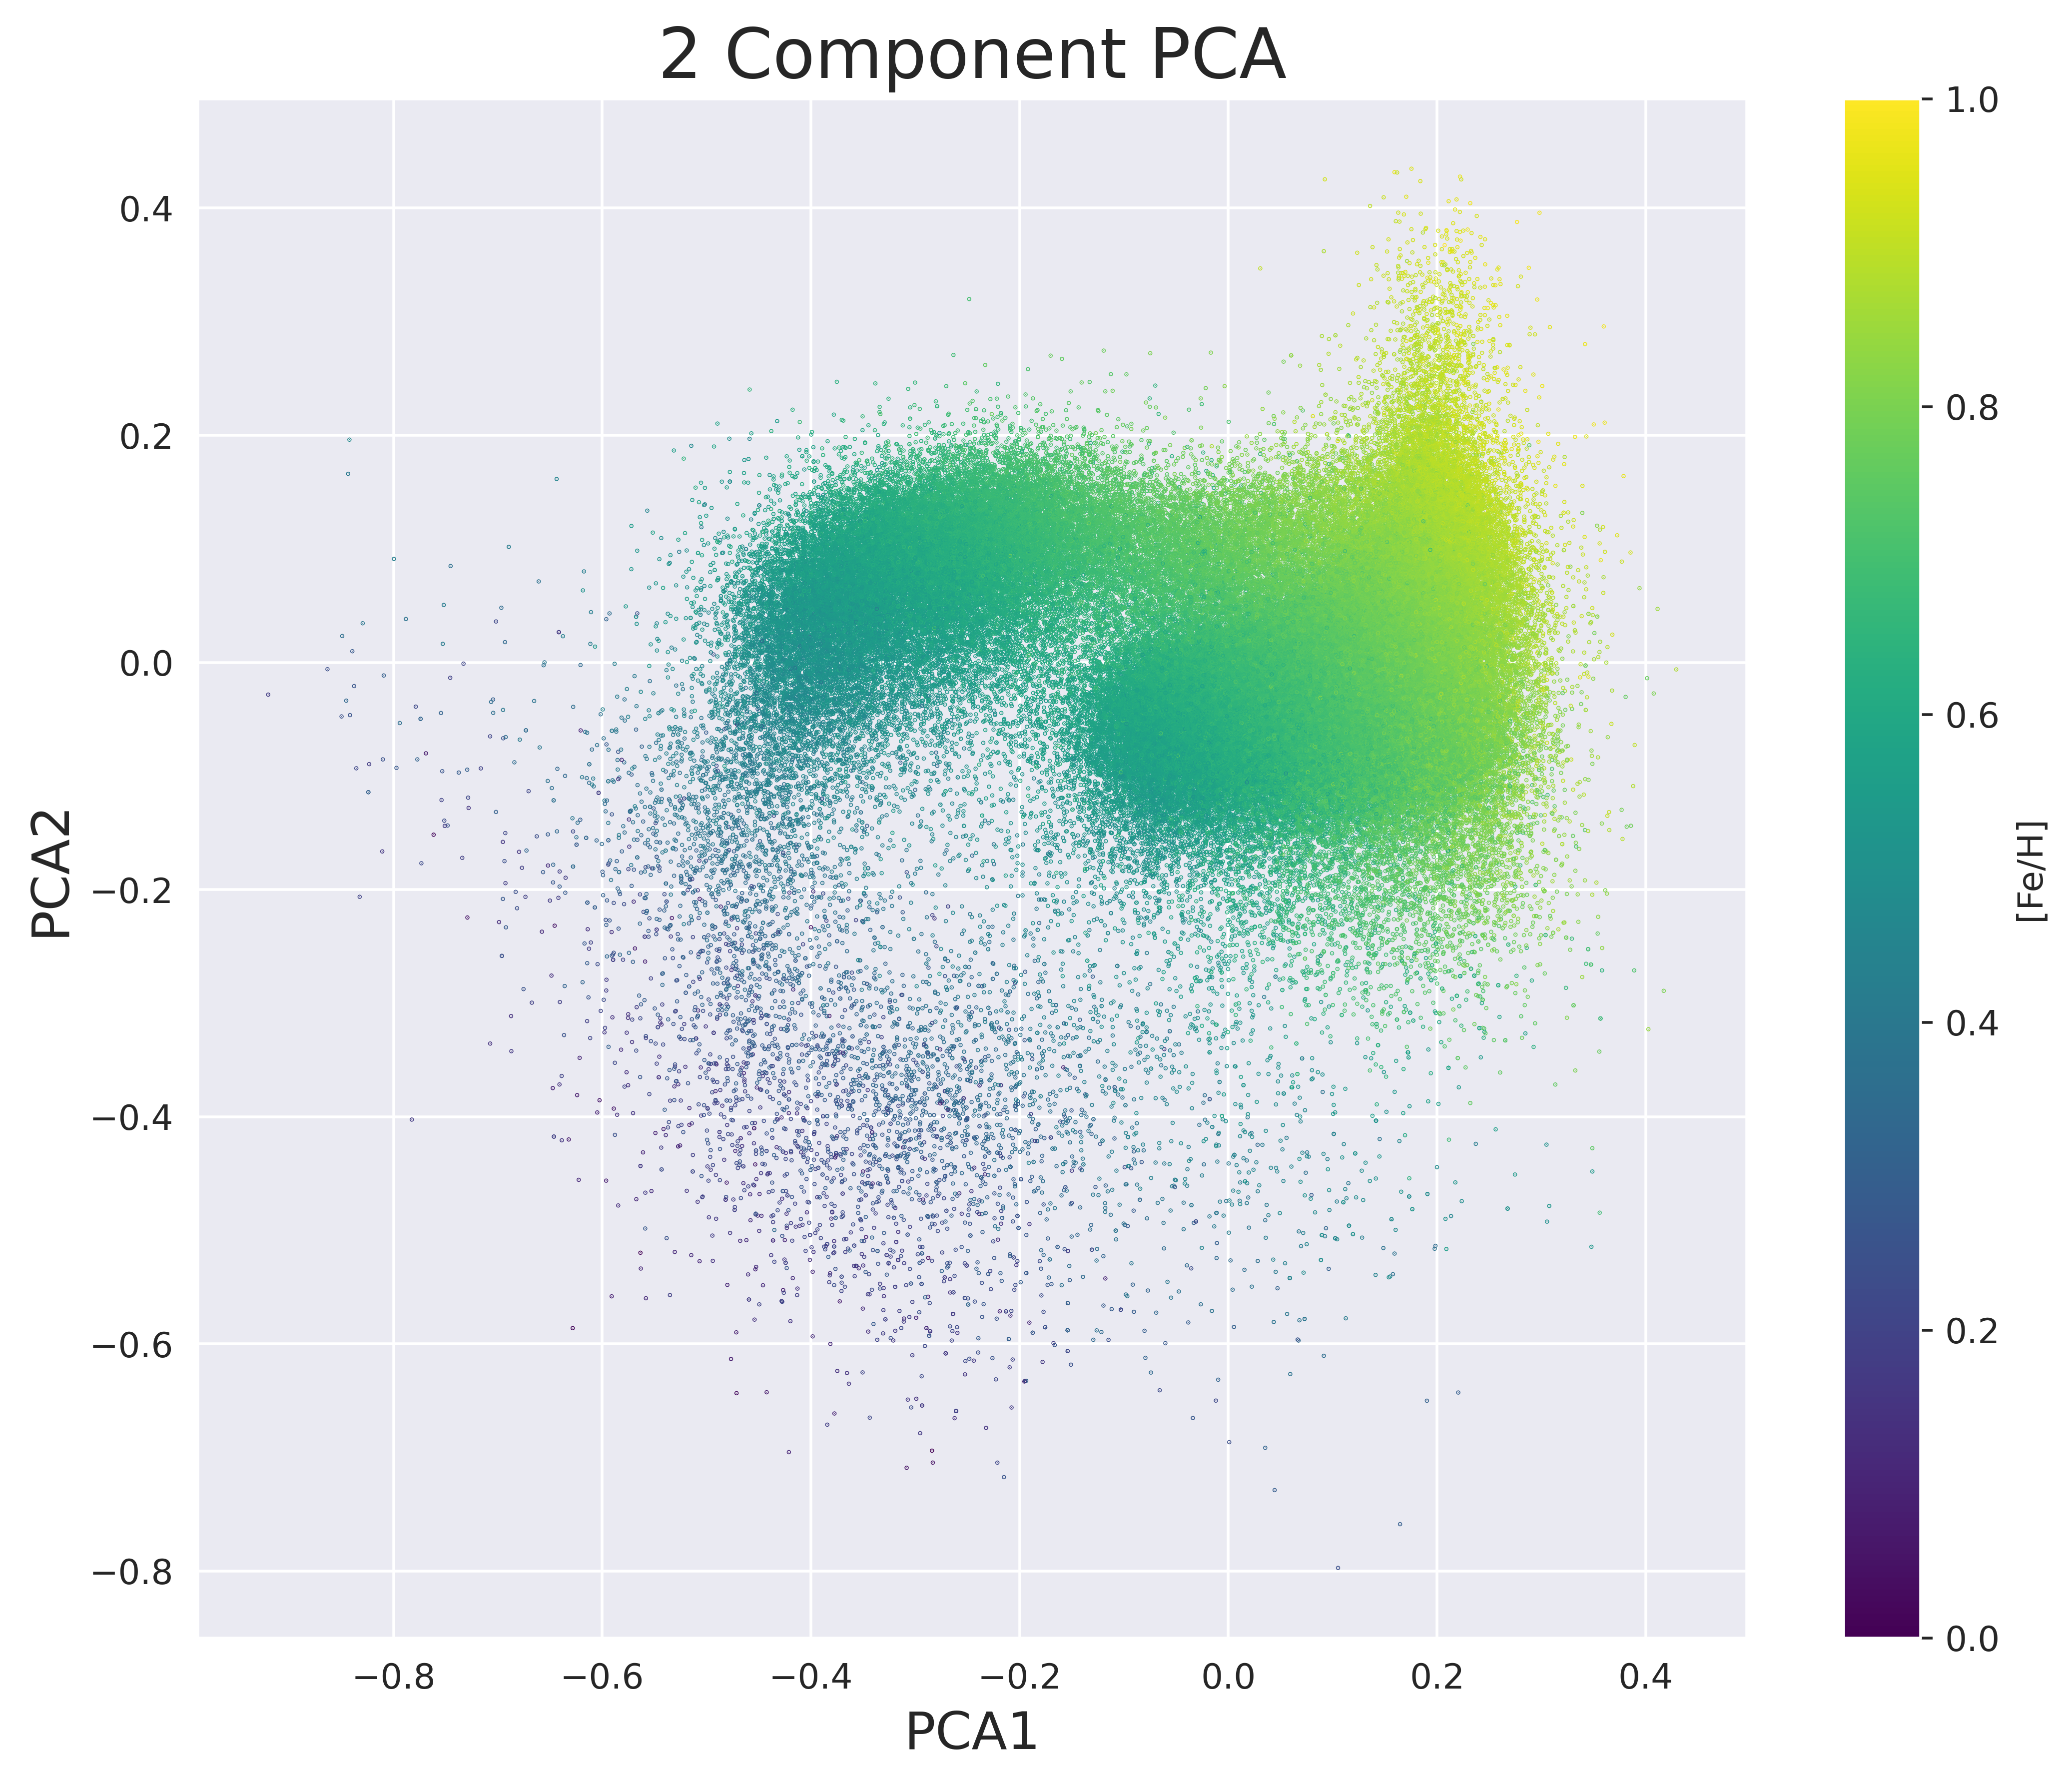

In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Verify and load the 2D PCA projection from the output folder
projection_file = os.path.join("output_dataset", "PCA_latent_space_2D.csv")
if not os.path.isfile(projection_file):
    raise FileNotFoundError(f"2D projection file not found: {projection_file}")

data_pca_pd = pd.read_csv(projection_file)
print("2D projection loaded successfully.")

# Plot the 2D PCA result
fig = plt.figure(figsize=(10, 8), dpi=500)
ax = fig.add_subplot(1, 1, 1)
ax.set_xlabel('PCA1', fontsize=15)
ax.set_ylabel('PCA2', fontsize=15)
ax.set_title('2 Component PCA', fontsize=20)

# Assuming the projection file has columns: 'apogee_id', '0', '1'
# Plot the scatter plot using PCA components and color coded by [Fe/H]
sc = ax.scatter(data_pca_pd.iloc[:, 1], data_pca_pd.iloc[:, 2], s=0.05, c=data['FE_H'], cmap='viridis')
plt.colorbar(sc, label='[Fe/H]')
plt.show()


In [84]:
data.describe()

,M_H,VMICRO,VMACRO,C_FE,CI_FE,N_FE,O_FE,NA_FE,MG_FE,AL_FE,SI_FE,S_FE,K_FE,CA_FE,TI_FE,V_FE,CR_FE,MN_FE,NI_FE,FE_H
count,453952.000000,453952.000000,453952.000000,453952.000000,453952.000000,453952.000000,453952.000000,453952.000000,453952.000000,453952.000000,453952.000000,453952.000000,453952.000000,453952.000000,453952.000000,453952.000000,453952.000000,453952.000000,453952.000000,453952.000000
mean,-0.191619,1.137900,2.237002,-0.009587,-0.021271,0.150533,0.130233,-0.043343,0.107964,0.106354,0.082315,0.091111,0.097143,0.041148,0.024947,-0.046567,-0.060688,-0.025461,0.032734,-0.193828
std,0.313735,0.509432,1.784414,0.109686,0.130222,0.195094,0.134144,0.333050,0.117183,0.125091,0.082687,0.161220,0.163715,0.086410,0.171877,0.242606,0.203191,0.104591,0.051951,0.312394
min,-2.247800,0.299999,0.000000,-1.478700,-1.491800,-0.689270,-0.739147,-2.524606,-0.662947,-1.172019,-0.664879,-0.855658,-2.641107,-0.871224,-0.928604,-2.485178,-2.685542,-2.255568,-2.117740,-2.198900
25%,-0.374060,0.780477,0.000000,-0.065501,-0.095401,0.062320,0.043457,-0.109348,0.028383,0.032111,0.025150,-0.011015,0.010489,-0.012243,-0.031807,-0.157939,-0.104866,-0.072417,0.005922,-0.376940
50%,-0.161170,1.232388,2.925625,-0.005616,-0.022559,0.168820,0.102752,0.012183,0.077435,0.098601,0.063348,0.059432,0.084273,0.027105,0.036066,-0.045237,-0.019209,-0.020398,0.035310,-0.161900
75%,0.027606,1.477100,3.564826,0.057690,0.055785,0.244410,0.202783,0.116802,0.161073,0.181166,0.119572,0.168995,0.185144,0.081353,0.116610,0.086258,0.035814,0.031632,0.063582,0.026444
max,0.648950,4.799986,11.014530,0.896040,1.005080,1.930400,0.983141,1.815727,0.805033,1.348811,0.963991,1.054192,1.637649,0.972755,1.014103,2.326922,1.460354,1.680942,1.327220,0.616290


In [85]:
import cuml
import cudf
pca = cuml.decomposition.PCA(n_components=2)
data_cudf = cudf.DataFrame.from_pandas(data)

data_pca = pca.fit_transform(data_cudf)

# data pca to pandas
data_pca_pd = data_pca.to_pandas()

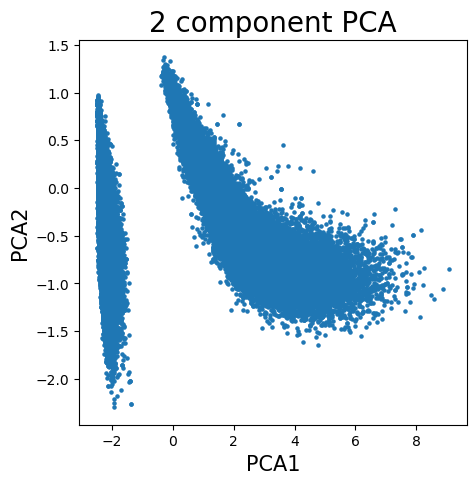

In [86]:
# plot the PCA
import matplotlib.pyplot as plt

fig = plt.figure(figsize = (5,5))
ax = fig.add_subplot(1,1,1)
ax.set_xlabel('PCA1', fontsize = 15)
ax.set_ylabel('PCA2', fontsize = 15)
ax.set_title('2 component PCA', fontsize = 20)
plt.scatter(data_pca_pd[0], data_pca_pd[1], s=5)
plt.show()  



In [87]:
# to pandas

In [ ]:
from cuml.manifold import UMAP

umap = UMAP(n_neighbors=15,
    min_dist=0.1,  # tester 0.1, 0.3, 0.5, etc.
    n_components=2,
    random_state=42,
    metric="euclidean",
            verbose=True)
data_umap = umap.fit_transform(data_cudf)


In [ ]:
# plot the UMAP

data_umap_pd = data_umap.to_pandas()

fig = plt.figure(figsize = (5,5))
ax = fig.add_subplot(1,1,1)
ax.set_xlabel('UMAP1', fontsize = 15)
ax.set_ylabel('UMAP2', fontsize = 15)

ax.set_title('2 component UMAP', fontsize = 20)
plt.scatter(data_umap_pd[0], data_umap_pd[1], s=1)
plt.show()

In [96]:
data_umap_pd.describe()

,0,1
count,453952.000000,453952.000000
mean,0.001358,0.186289
std,9.297642,9.124111
min,-206.810516,-234.628784
25%,-4.275593,-3.997229
50%,-0.322937,0.464717
75%,4.711510,3.693076
max,218.809616,239.518829
